# Spin SDP Framework Demo

This notebook demonstrates the usage of the `spin_sdp` package to analyze the transverse field Ising model.

In [1]:
import cvxpy as cp
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt

from spin_sdp import (
    ising_hamiltonian,
    magnetization_qutip,
    gibbs_state_from_spectrum,
    npa_level,
    moment_matrix_dict,
    build_sdp_variables,
    dict_to_cvxpy_matrix_from_expr,
    ising_energy_expr,
    average_magnetization,
    ising_pauli_symbolic_terms,
    build_diagonality_constraints,
    build_lambda_matrix
)

## 1. Exact Diagonalization

In [2]:
# Model parameters
N = 2
J = 1.0
h = 1.0
k = 0.3
boundary = "periodic"
beta = 1.0
axis = 'z'

# Construct Hamiltonian
H = ising_hamiltonian(N, J, h, k, boundary)
eigenvalues, eigenstates = H.eigenstates()

# Observables
O_qutip = magnetization_qutip(N, axis=axis, average=True)

# Ground state
E0 = eigenvalues[0]
E1 = eigenvalues[1] if len(eigenvalues) > 1 else E0 + 1.0
O_exact_gs = qt.expect(O_qutip, eigenstates[0])

# Thermal state
rho_gibbs = gibbs_state_from_spectrum(eigenvalues, eigenstates, beta)
O_exact_thermal = qt.expect(O_qutip, rho_gibbs)

print(f"Exact ground state energy E0/N: {E0/N}")
print(f"Exact ground state avg {axis}-mag: {O_exact_gs}")
print(f"Exact thermal state avg {axis}-mag: {O_exact_thermal}")

Exact ground state energy E0/N: -1.5539983075539883
Exact ground state avg z-mag: 0.7487039269448222
Exact thermal state avg z-mag: 0.45115245999913245


## 2. SDP Relaxation (Ground State Energy)

In [3]:
# SDP parameters
NPA_level = 2
solver = "SCS"

# 1. Generate basis
relaxation = npa_level(N=N, NPA_level=NPA_level)
print(f"Basis size: {len(relaxation)}")

# 2. Build Moment Matrix Dictionary
M_dict = moment_matrix_dict(relaxation)
all_labels = sorted({label for (_, label) in M_dict.values()})

# 3. Define Physical Variables
x = cp.Variable(N, name="x")
z = cp.Variable(N, name="z")
zz = cp.Variable(N-1 if boundary == "open" else N, name="zz")

# 4. Map labels to expressions
label_to_expr, extra_moments = build_sdp_variables(x, z, zz, all_labels, boundary, N)

# 5. Construct SDP Matrix
M = dict_to_cvxpy_matrix_from_expr(M_dict, label_to_expr)

# 6. Define Objective (Energy)
H_energy = ising_energy_expr(J, h, k, boundary, x, z, zz)

# 7. Constraints
constraints = [
    x >= -1, x <= 1,
    z >= -1, z <= 1,
    zz >= -1, zz <= 1,
    M >> 0  # PSD constraint
]
if extra_moments:
    extra_vec = cp.hstack(list(extra_moments.values()))
    constraints += [extra_vec >= -1, extra_vec <= 1]

# 8. Solve
prob = cp.Problem(cp.Minimize(H_energy), constraints)
prob.solve(solver=solver, verbose=False)

print(f"SDP Energy Lower Bound E_lb/N: {prob.value/N}")
print(f"Exact Energy E0/N: {E0/N}")

# Keep for next cell
E_lb_val = prob.value

Basis size: 37


/Users/cisco/_Code/MyRepositories/ThermalSDP/.venv/lib/python3.13/site-packages/cvxpy/problems/problem.py:164: UserWarning: Constraint #6 contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn(f"Constraint #{i} contains too many subexpressions. "


SDP Energy Lower Bound E_lb/N: -1.7110235436640175
Exact Energy E0/N: -1.5539983075539883


## 3. SDP Relaxation (Ground State Observable Bounds)
We can bound an observable <O> subject to <H> ~ E0.

In [4]:
E_up = E1 # Simplification: Assuming gap or using 1st excited enegy as upper bound for GS subspace constraint
# Or just use E0 from exact if we want to check consistency, or the SDP E_lb we noticed.
# The original notebook used: E_up, E_lb = eigenvalues[1], eigenvalues[0]
# But here we want to allow some slack if we use the SDP E_lb
# Let's use the exact energies for the constraint to see if we can bound the observable tight.

print(f"Constraining Energy between {E_lb_val} and {E1}")

# Re-use variables and M from previous cell, or rebuild
# Adding energy constraints to existing list
constraints_obs = list(constraints)
constraints_obs += [H_energy <= E1]
constraints_obs += [H_energy >= E_lb_val] # The lower bound found by SDP

O_obj = average_magnetization(axis, N, label_to_expr)

prob_O_min = cp.Problem(cp.Minimize(O_obj), constraints_obs)
prob_O_min.solve(solver=solver, verbose=False)

prob_O_max = cp.Problem(cp.Maximize(O_obj), constraints_obs)
prob_O_max.solve(solver=solver, verbose=False)

print(f"Exact ground state avg {axis}-magnetization: {O_exact_gs}")
print(f"SDP Min: {prob_O_min.value}")
print(f"SDP Max: {prob_O_max.value}")

Constraining Energy between -3.422047087328035 and -1.731447906091391
Exact ground state avg z-magnetization: 0.7487039269448222
SDP Min: -0.9842876823741546
SDP Max: 0.9999989270654357


## 4. SDP Relaxation (Thermal State Observable Bounds)
Using Lasserre hierarchy extended with thermal constraints (diagonality + Gibbs condition).

h_labels = ['I', 'x0', 'y0', 'z0', 'x1', 'y1', 'z1']
Solving for beta = 1.0...
  Exact: 0.4512, SDP: [0.3528, 0.7487]
Solving for beta = 1.75...
  Exact: 0.6281, SDP: [0.2365, 0.7487]
Solving for beta = 2.5...
  Exact: 0.7034, SDP: [0.1237, 0.7487]
Solving for beta = 3.25...
  Exact: 0.7322, SDP: [0.0303, 0.7487]
Solving for beta = 4.0...
  Exact: 0.7428, SDP: [-0.0399, 0.7487]


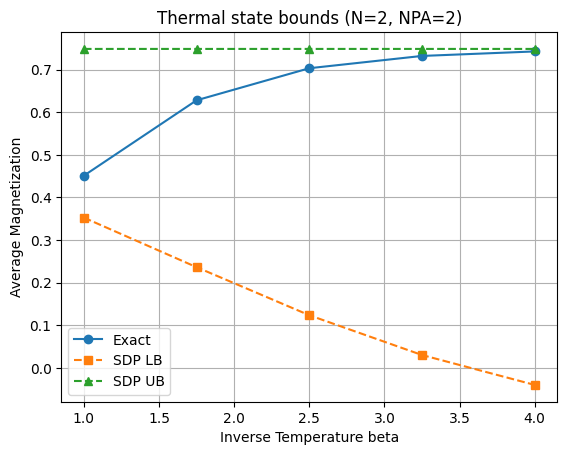

In [5]:
# Parameters
h_basis_locality = max(1, NPA_level - 1)
beta_list = np.linspace(1, 4, 5) # Smaller range for demo speed
Delta_list = [0.5, 1.0, 2.0]

# Basis {h_j}
h_labels = npa_level(N=N, NPA_level=h_basis_locality, collapse_rule=True)
print("h_labels =", h_labels)

# Symbolic H
H_terms = ising_pauli_symbolic_terms(N, J, h, k, boundary)

exact_O_vals = []
sdp_lb_vals = []
sdp_ub_vals = []

for beta in beta_list:
    print(f"Solving for beta = {beta}...")

    # Exact
    rho_beta = gibbs_state_from_spectrum(eigenvalues, eigenstates, beta)
    O_exact = qt.expect(O_qutip, rho_beta)
    exact_O_vals.append(O_exact)

    # SDP
    # For thermal, we rebuild variables/constraints per beta if we were optimizing Lambda variables,
    # but here Lambda is built from Moment Matrix variables which are static.
    # However, Lambda depends on beta, so constraints change.
    
    # Re-use x, z, zz, Label_to_expr from global scope? Yes.
    # Re-build base constraints
    current_constraints = [
        x >= -1, x <= 1,
        z >= -1, z <= 1,
        zz >= -1, zz <= 1,
        M >> 0,
    ]
    if extra_moments:
        extra_vec = cp.hstack(list(extra_moments.values()))
        current_constraints += [extra_vec >= -1, extra_vec <= 1]

    # Diagonality
    diagonality = build_diagonality_constraints(H_terms, h_labels, label_to_expr)
    current_constraints += diagonality

    # Gibbs Lambda
    for Delta in Delta_list:
        Lambda = build_lambda_matrix(beta, Delta, H_terms, h_labels, label_to_expr)
        current_constraints.append(Lambda >> 0)

    # Objective
    O_obj = average_magnetization(axis, N, label_to_expr)

    # Solve Min
    prob_min = cp.Problem(cp.Minimize(O_obj), current_constraints)
    try:
        prob_min.solve(solver=solver, verbose=False)
        sdp_lb = prob_min.value
    except Exception as e:
        print("Solver error:", e)
        sdp_lb = None
        
    sdp_lb_vals.append(sdp_lb)

    # Solve Max
    prob_max = cp.Problem(cp.Maximize(O_obj), current_constraints)
    try:
        prob_max.solve(solver=solver, verbose=False)
        sdp_ub = prob_max.value
    except:
        sdp_ub = None
    sdp_ub_vals.append(sdp_ub)
    
    print(f"  Exact: {O_exact:.4f}, SDP: [{sdp_lb:.4f}, {sdp_ub:.4f}]")

# Plot
if all(v is not None for v in sdp_lb_vals):
    plt.figure()
    plt.plot(beta_list, exact_O_vals, "-o", label="Exact")
    plt.plot(beta_list, sdp_lb_vals, "--s", label="SDP LB")
    plt.plot(beta_list, sdp_ub_vals, "--^", label="SDP UB")
    plt.xlabel("Inverse Temperature beta")
    plt.ylabel("Average Magnetization")
    plt.legend()
    plt.grid(True)
    plt.title(f"Thermal state bounds (N={N}, NPA={NPA_level})")
    plt.show()